# Alberta Expense Analysis (2011-12 to 2024-25)

Where does every dollar of Alberta's operating budget go? This notebook analyzes
14 years of ministry-level spending data extracted from provincial budget PDFs,
normalized into 5 consistent categories across government restructurings.

**Categories:** Health | Education (K-12) | Advanced Education | Social Services | Other

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path

PROJECT = Path(r"C:\Users\Casper Ruta\Desktop\Kacper Ruta 2026\Alberta Budget Analysis")
PLOTS = PROJECT / "plots"
PLOTS.mkdir(exist_ok=True)

# ── Dark theme palette ──
BG       = "#0D1117"
CARD_BG  = "#161B22"
GRID     = "#21262D"
TEXT     = "#C9D1D9"
MUTED    = "#8B949E"

# Ministry category colours
COLORS = {
    "Health":            "#F85149",  # red
    "Education (K-12)":  "#58A6FF",  # blue
    "Advanced Education": "#56D364", # green
    "Social Services":   "#FFB703",  # amber
    "Other":             "#8B949E",  # grey
}
CATS = list(COLORS.keys())

# Party shading
PC_C  = "#1B4F8A"
NDP_C = "#D4610A"
UCP_C = "#1A6B3C"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": CARD_BG,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT,
    "text.color": TEXT,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": GRID,
    "legend.facecolor": CARD_BG,
    "legend.edgecolor": GRID,
    "font.size": 11,
})

print("Setup complete.")

Setup complete.


## 1. Load & Prepare Data

In [2]:
# Load ministry expense data
df = pd.read_csv(PROJECT / "Data" / "ministry_expenses.csv")
wide = pd.read_csv(PROJECT / "Data" / "ministry_expenses_wide.csv", index_col=0)

# Fiscal year labels (short form for plotting)
years = sorted(wide.index)
labels = [y.split("-")[0][-2:] + "-" + y.split("-")[1] for y in years]

# Alberta midyear population (July, from StatsCan Table 17-10-0009-01)
POP = {
    "2011-12": 3787705, "2012-13": 3871947, "2013-14": 3978532,
    "2014-15": 4081271, "2015-16": 4150147, "2016-17": 4195427,
    "2017-18": 4237310, "2018-19": 4292556, "2019-20": 4355377,
    "2020-21": 4407495, "2021-22": 4431531, "2022-23": 4512731,
    "2023-24": 4688576, "2024-25": 4909030,
}

# Alberta CPI (All-items, annual average, 2002=100)
# Source: Statistics Canada Table 18-10-0004-01
CPI = {
    "2011-12": 119.9, "2012-13": 121.6, "2013-14": 123.9,
    "2014-15": 126.5, "2015-16": 128.0, "2016-17": 129.8,
    "2017-18": 132.3, "2018-19": 135.4, "2019-20": 137.0,
    "2020-21": 138.4, "2021-22": 143.9, "2022-23": 153.7,
    "2023-24": 158.5, "2024-25": 161.8,
}

# Add population and CPI to wide table
wide["population"] = wide.index.map(POP)
wide["cpi"] = wide.index.map(CPI)
wide["cpi_deflator"] = wide["cpi"].iloc[-1] / wide["cpi"]  # convert to 2024-25 dollars

# Per-capita columns ($ per person)
for cat in CATS:
    wide[f"{cat}_percapita"] = wide[cat] / wide["population"] * 1e6
wide["total_percapita"] = wide["total_operating"] / wide["population"] * 1e6

# Real (inflation-adjusted) columns
for cat in CATS:
    wide[f"{cat}_real"] = wide[cat] * wide["cpi_deflator"]
wide["total_real"] = wide["total_operating"] * wide["cpi_deflator"]
wide["total_real_percapita"] = wide["total_real"] / wide["population"] * 1e6

print(wide[["total_operating", "population", "cpi", "total_percapita", "total_real"]].to_string())

             total_operating  population    cpi  total_percapita    total_real
fiscal_year                                                                   
2011-12                34175     3787705  119.9      9022.613958  46117.723103
2012-13                36526     3871947  121.6      9433.496894  48601.207237
2013-14                37654     3978532  123.9      9464.294871  49172.051655
2014-15                38947     4081271  126.5      9542.860545  49815.214229
2015-16                43185     4150147  128.0     10405.655511  54588.539063
2016-17                46151     4195427  129.8     11000.310576  57528.750385
2017-18                46751     4237310  132.3     11033.179069  57175.448224
2018-19                48442     4292556  135.4     11285.117771  57887.116691
2019-20                49703     4355377  137.0     11411.870890  58700.331387
2020-21                50705     4407495  138.4     11504.267163  59277.955202
2021-22                52342     4431531  143.9     

## 2. Where Every Dollar Goes — Spending Composition

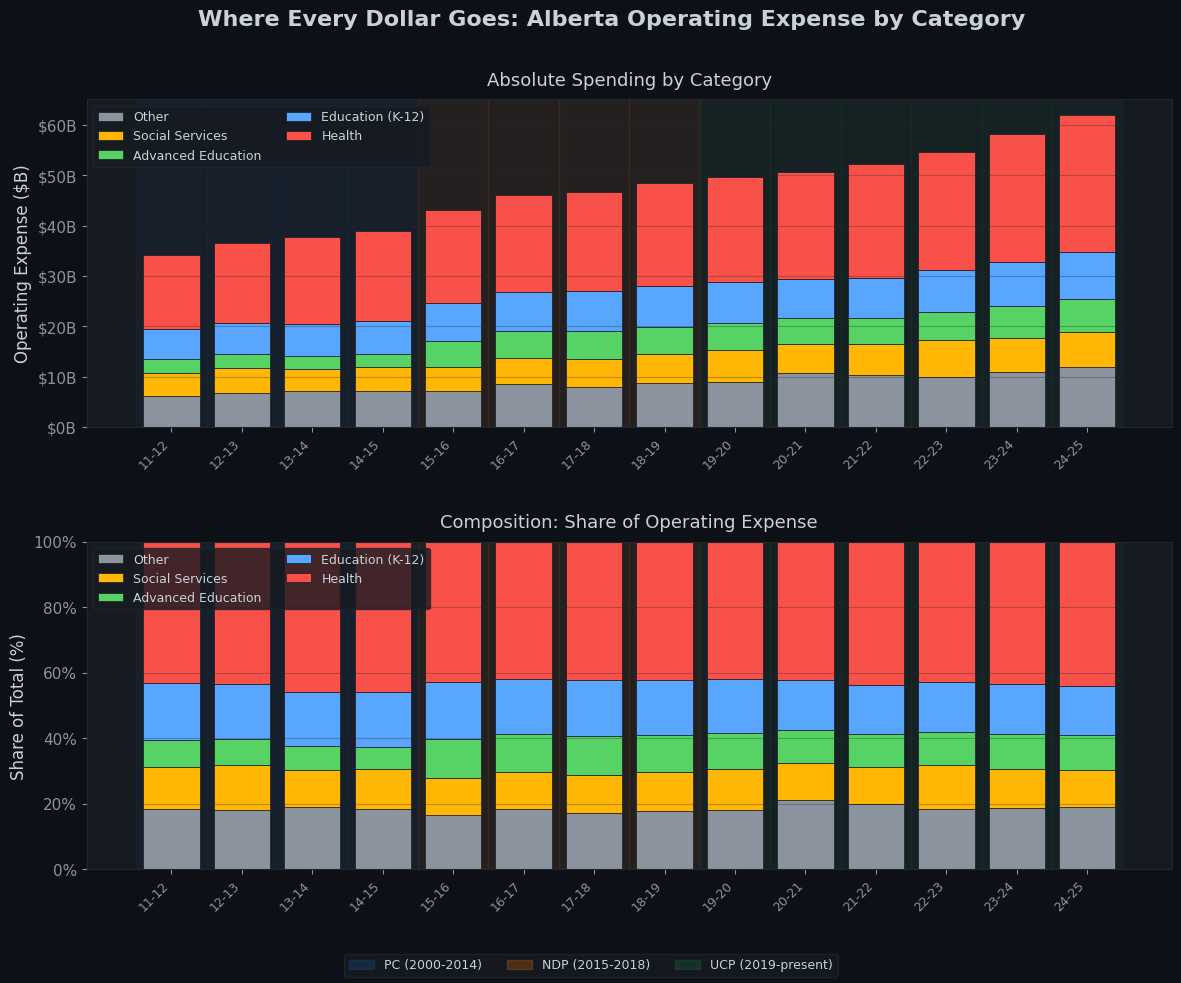

Saved: plots/expense_composition.png


In [3]:
def add_party_shading(ax, years, alpha=0.08):
    """Add subtle background shading for governing party eras."""
    x = np.arange(len(years))
    for i, yr in enumerate(years):
        start_yr = int("20" + yr[:2]) if int(yr[:2]) < 50 else int("19" + yr[:2])
        if start_yr <= 2014:
            color = PC_C
        elif start_yr <= 2018:
            color = NDP_C
        else:
            color = UCP_C
        ax.axvspan(i - 0.5, i + 0.5, color=color, alpha=alpha, zorder=0)


# ── Panel 1: Stacked area chart (absolute $B) ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"hspace": 0.35})
fig.suptitle("Where Every Dollar Goes: Alberta Operating Expense by Category",
             fontsize=16, fontweight="bold", y=0.97)

x = np.arange(len(years))
bottom = np.zeros(len(years))
stacks = {}
for cat in reversed(CATS):  # Other on bottom, Health on top
    vals = wide.loc[years, cat].values / 1000  # convert to $B
    stacks[cat] = vals

# Stack in order: Other, Social, AdvEd, K-12, Health
stack_order = list(reversed(CATS))
bottom = np.zeros(len(years))
for cat in stack_order:
    vals = stacks[cat]
    ax1.bar(x, vals, bottom=bottom, color=COLORS[cat], label=cat, width=0.8, edgecolor=CARD_BG, linewidth=0.5)
    bottom += vals

add_party_shading(ax1, labels)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("Operating Expense ($B)", fontsize=12)
ax1.set_title("Absolute Spending by Category", fontsize=13, pad=10)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0fB"))
ax1.legend(loc="upper left", fontsize=9, ncol=2)
ax1.grid(axis="y", alpha=0.3)

# ── Panel 2: 100% stacked bar chart ──
totals = wide.loc[years, "total_operating"].values
bottom = np.zeros(len(years))
for cat in stack_order:
    vals = wide.loc[years, cat].values / totals * 100
    ax2.bar(x, vals, bottom=bottom, color=COLORS[cat], label=cat, width=0.8, edgecolor=CARD_BG, linewidth=0.5)
    bottom += vals

add_party_shading(ax2, labels)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Share of Total (%)", fontsize=12)
ax2.set_title("Composition: Share of Operating Expense", fontsize=13, pad=10)
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.legend(loc="upper left", fontsize=9, ncol=2)
ax2.grid(axis="y", alpha=0.3)

# Party legend
party_patches = [
    mpatches.Patch(color=PC_C, alpha=0.3, label="PC (2000-2014)"),
    mpatches.Patch(color=NDP_C, alpha=0.3, label="NDP (2015-2018)"),
    mpatches.Patch(color=UCP_C, alpha=0.3, label="UCP (2019-present)"),
]
fig.legend(handles=party_patches, loc="lower center", ncol=3, fontsize=9,
           frameon=True, facecolor=CARD_BG, edgecolor=GRID)

plt.savefig(PLOTS / "expense_composition.png", dpi=200, bbox_inches="tight",
            facecolor=BG, edgecolor="none")
plt.show()
print("Saved: plots/expense_composition.png")

## 3. Per-Capita Spending

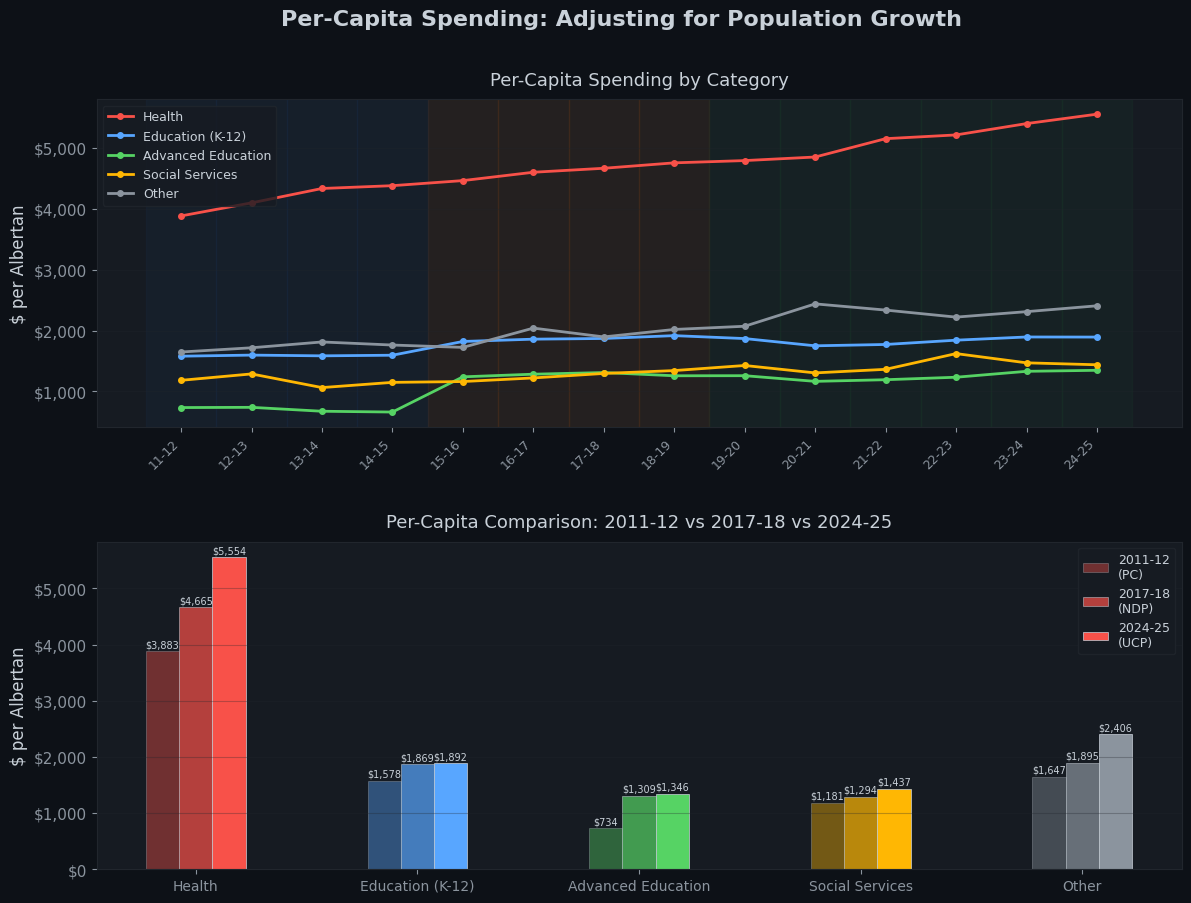

Saved: plots/expense_percapita.png


In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"hspace": 0.35})
fig.suptitle("Per-Capita Spending: Adjusting for Population Growth",
             fontsize=16, fontweight="bold", y=0.97)

# ── Panel 1: Per-capita line chart by category ──
for cat in CATS:
    vals = wide.loc[years, f"{cat}_percapita"].values
    ax1.plot(x, vals, color=COLORS[cat], marker="o", markersize=4, linewidth=2, label=cat)

add_party_shading(ax1, labels)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("$ per Albertan", fontsize=12)
ax1.set_title("Per-Capita Spending by Category", fontsize=13, pad=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x:,.0f}"))
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# ── Panel 2: Grouped bar comparison (3 years) ──
compare_years = ["2011-12", "2017-18", "2024-25"]
compare_labels = ["2011-12\n(PC)", "2017-18\n(NDP)", "2024-25\n(UCP)"]
bar_width = 0.15
bar_x = np.arange(len(CATS))

for i, (yr, lbl) in enumerate(zip(compare_years, compare_labels)):
    vals = [wide.loc[yr, f"{cat}_percapita"] for cat in CATS]
    offset = (i - 1) * bar_width
    bars = ax2.bar(bar_x + offset, vals, bar_width, label=lbl,
                   color=[COLORS[c] for c in CATS], alpha=0.4 + 0.3 * i,
                   edgecolor=TEXT, linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f"${v:,.0f}", ha="center", va="bottom", fontsize=7, color=TEXT)

ax2.set_xticks(bar_x)
ax2.set_xticklabels(CATS, fontsize=10)
ax2.set_ylabel("$ per Albertan", fontsize=12)
ax2.set_title("Per-Capita Comparison: 2011-12 vs 2017-18 vs 2024-25", fontsize=13, pad=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x:,.0f}"))
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.savefig(PLOTS / "expense_percapita.png", dpi=200, bbox_inches="tight",
            facecolor=BG, edgecolor="none")
plt.show()
print("Saved: plots/expense_percapita.png")

## 4. Inflation-Adjusted (Real) Spending

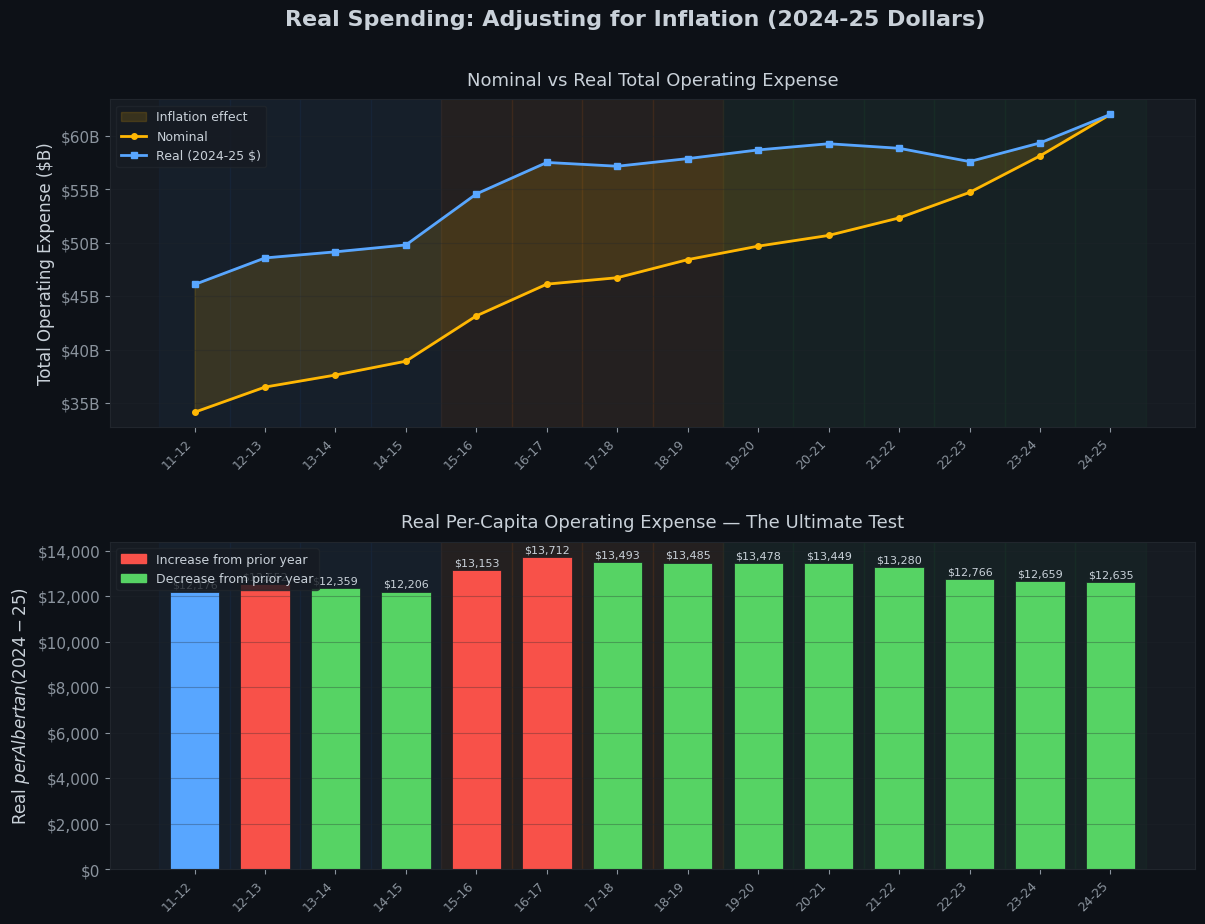

Saved: plots/expense_real_spending.png


In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"hspace": 0.35})
fig.suptitle("Real Spending: Adjusting for Inflation (2024-25 Dollars)",
             fontsize=16, fontweight="bold", y=0.97)

# ── Panel 1: Nominal vs Real total operating expense ──
nominal = wide.loc[years, "total_operating"].values / 1000
real = wide.loc[years, "total_real"].values / 1000

ax1.fill_between(x, nominal, real, alpha=0.15, color="#FFB703", label="Inflation effect")
ax1.plot(x, nominal, color="#FFB703", marker="o", markersize=4, linewidth=2, label="Nominal")
ax1.plot(x, real, color="#58A6FF", marker="s", markersize=4, linewidth=2, label="Real (2024-25 $)")

add_party_shading(ax1, labels)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("Total Operating Expense ($B)", fontsize=12)
ax1.set_title("Nominal vs Real Total Operating Expense", fontsize=13, pad=10)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0fB"))
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# ── Panel 2: Real per-capita spending ──
real_pc = wide.loc[years, "total_real_percapita"].values

# Color bars by change direction
bar_colors = []
for i, v in enumerate(real_pc):
    if i == 0:
        bar_colors.append("#58A6FF")
    elif v >= real_pc[i - 1]:
        bar_colors.append("#F85149")  # increase = red (spending up)
    else:
        bar_colors.append("#56D364")  # decrease = green (spending down)

ax2.bar(x, real_pc, color=bar_colors, width=0.7, edgecolor=CARD_BG, linewidth=0.5)

# Add value labels on top
for i, v in enumerate(real_pc):
    ax2.text(i, v + 100, f"${v:,.0f}", ha="center", va="bottom", fontsize=8, color=TEXT)

add_party_shading(ax2, labels)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Real $ per Albertan (2024-25 $)", fontsize=12)
ax2.set_title("Real Per-Capita Operating Expense — The Ultimate Test", fontsize=13, pad=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x:,.0f}"))
ax2.grid(axis="y", alpha=0.3)

# Legend for bar colors
increase_patch = mpatches.Patch(color="#F85149", label="Increase from prior year")
decrease_patch = mpatches.Patch(color="#56D364", label="Decrease from prior year")
ax2.legend(handles=[increase_patch, decrease_patch], loc="upper left", fontsize=9)

plt.savefig(PLOTS / "expense_real_spending.png", dpi=200, bbox_inches="tight",
            facecolor=BG, edgecolor="none")
plt.show()
print("Saved: plots/expense_real_spending.png")

## 5. Health Spending Deep Dive

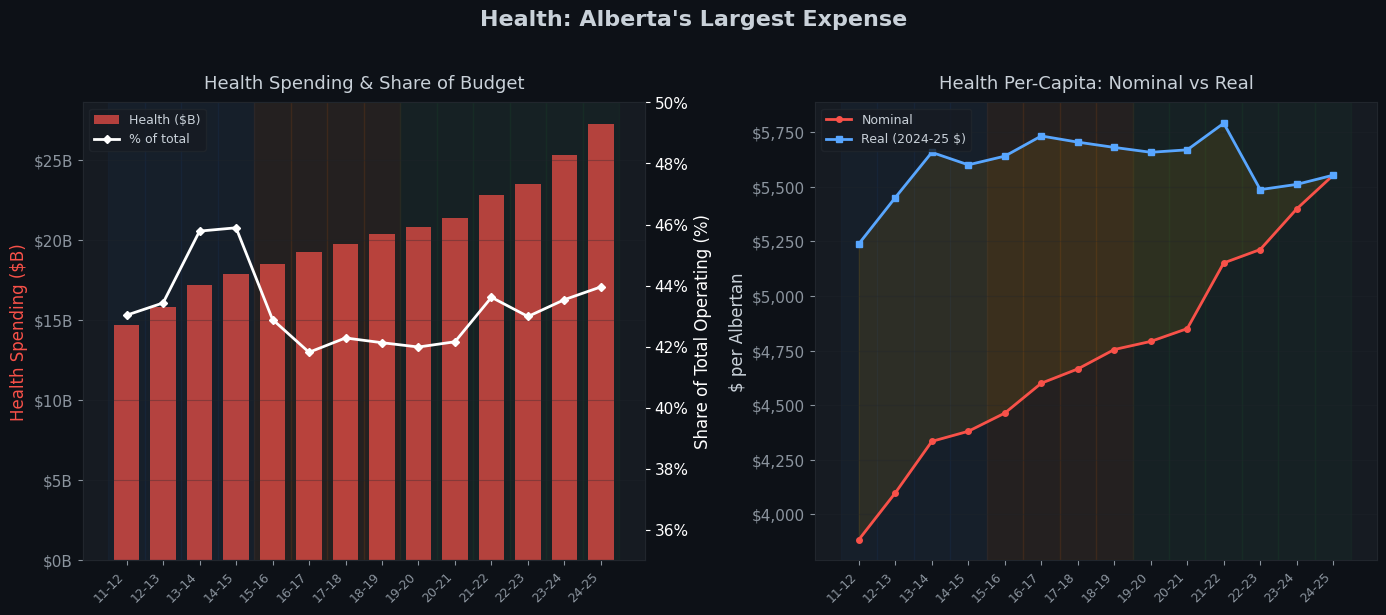

Saved: plots/expense_health_deep_dive.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Health: Alberta's Largest Expense",
             fontsize=16, fontweight="bold", y=1.02)

# ── Left: Health spending absolute + share ──
health_vals = wide.loc[years, "Health"].values / 1000
health_pct = wide.loc[years, "Health"].values / wide.loc[years, "total_operating"].values * 100

color_h = COLORS["Health"]
ax1.bar(x, health_vals, color=color_h, width=0.7, alpha=0.7, label="Health ($B)")
ax1.set_ylabel("Health Spending ($B)", fontsize=12, color=color_h)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.0fB"))
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax1.set_title("Health Spending & Share of Budget", fontsize=13, pad=10)
ax1.grid(axis="y", alpha=0.3)
add_party_shading(ax1, labels)

ax1b = ax1.twinx()
ax1b.plot(x, health_pct, color="#FFFFFF", marker="D", markersize=4, linewidth=2, label="% of total")
ax1b.set_ylabel("Share of Total Operating (%)", fontsize=12, color="#FFFFFF")
ax1b.set_ylim(35, 50)
ax1b.tick_params(axis="y", colors="#FFFFFF")
ax1b.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

# ── Right: Health per-capita (nominal vs real) ──
h_pc_nom = wide.loc[years, "Health_percapita"].values
h_pc_real = (wide.loc[years, "Health"].values * wide.loc[years, "cpi_deflator"].values) / wide.loc[years, "population"].values * 1e6

ax2.plot(x, h_pc_nom, color=color_h, marker="o", markersize=4, linewidth=2, label="Nominal")
ax2.plot(x, h_pc_real, color="#58A6FF", marker="s", markersize=4, linewidth=2, label="Real (2024-25 $)")
ax2.fill_between(x, h_pc_nom, h_pc_real, alpha=0.1, color="#FFB703")

ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("$ per Albertan", fontsize=12)
ax2.set_title("Health Per-Capita: Nominal vs Real", fontsize=13, pad=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x:,.0f}"))
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(axis="y", alpha=0.3)
add_party_shading(ax2, labels)

plt.tight_layout()
plt.savefig(PLOTS / "expense_health_deep_dive.png", dpi=200, bbox_inches="tight",
            facecolor=BG, edgecolor="none")
plt.show()
print("Saved: plots/expense_health_deep_dive.png")

## 6. Growth Rates by Category

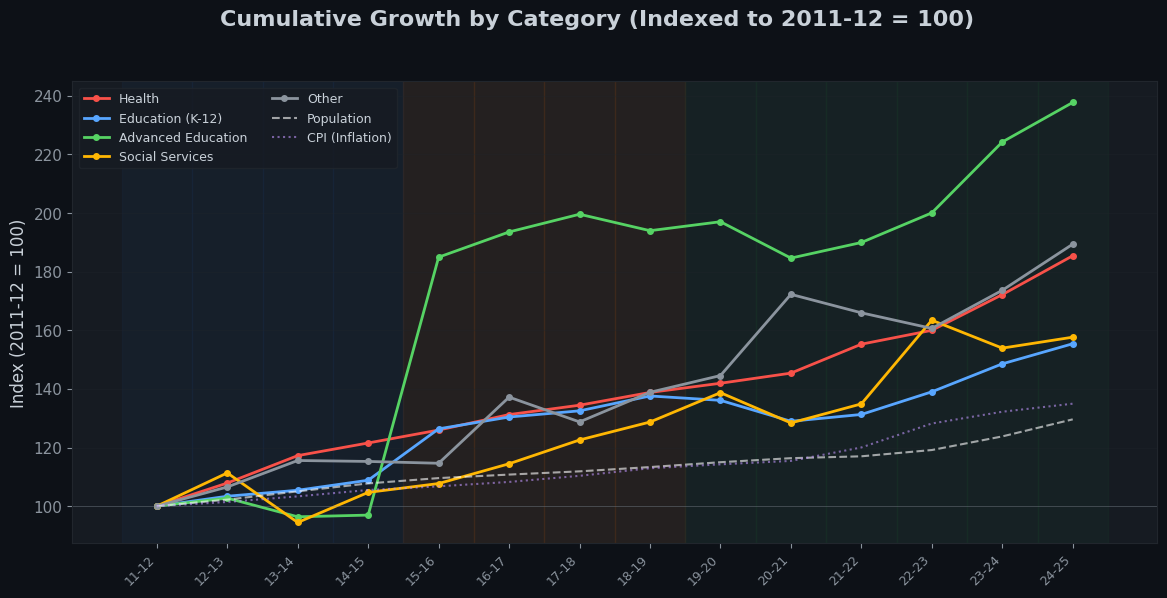

Saved: plots/expense_growth_indexed.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Cumulative Growth by Category (Indexed to 2011-12 = 100)",
             fontsize=16, fontweight="bold", y=1.0)

base_year = years[0]
for cat in CATS:
    base_val = wide.loc[base_year, cat]
    indexed = wide.loc[years, cat].values / base_val * 100
    ax.plot(x, indexed, color=COLORS[cat], marker="o", markersize=4, linewidth=2, label=cat)

# Population growth line
pop_base = wide.loc[base_year, "population"]
pop_indexed = wide.loc[years, "population"].values / pop_base * 100
ax.plot(x, pop_indexed, color="#FFFFFF", linestyle="--", linewidth=1.5, alpha=0.6, label="Population")

# CPI line
cpi_base = wide.loc[base_year, "cpi"]
cpi_indexed = wide.loc[years, "cpi"].values / cpi_base * 100
ax.plot(x, cpi_indexed, color="#BD93F9", linestyle=":", linewidth=1.5, alpha=0.6, label="CPI (Inflation)")

add_party_shading(ax, labels)
ax.axhline(y=100, color=MUTED, linestyle="-", linewidth=0.5, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Index (2011-12 = 100)", fontsize=12)
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(axis="y", alpha=0.3)

plt.savefig(PLOTS / "expense_growth_indexed.png", dpi=200, bbox_inches="tight",
            facecolor=BG, edgecolor="none")
plt.show()
print("Saved: plots/expense_growth_indexed.png")

## 7. Key Findings

In [8]:
# Summary statistics
first = years[0]
last = years[-1]

print("="*60)
print("KEY FINDINGS: Alberta Expense Analysis 2011-12 to 2024-25")
print("="*60)

total_first = wide.loc[first, "total_operating"]
total_last = wide.loc[last, "total_operating"]
print(f"\nTotal Operating Expense:")
print(f"  {first}: ${total_first/1000:,.1f}B  ->  {last}: ${total_last/1000:,.1f}B")
print(f"  Growth: {(total_last/total_first - 1)*100:.1f}%")

pop_first = wide.loc[first, "population"]
pop_last = wide.loc[last, "population"]
print(f"\nPopulation:")
print(f"  {first}: {pop_first/1e6:,.2f}M  ->  {last}: {pop_last/1e6:,.2f}M")
print(f"  Growth: {(pop_last/pop_first - 1)*100:.1f}%")

rpc_first = wide.loc[first, "total_real_percapita"]
rpc_last = wide.loc[last, "total_real_percapita"]
print(f"\nReal Per-Capita Spending (2024-25 $):")
print(f"  {first}: ${rpc_first:,.0f}  ->  {last}: ${rpc_last:,.0f}")
print(f"  Change: {(rpc_last/rpc_first - 1)*100:+.1f}%")

print(f"\nCategory Growth ({first} to {last}):")
for cat in CATS:
    v1 = wide.loc[first, cat]
    v2 = wide.loc[last, cat]
    pct = (v2/v1 - 1) * 100
    share1 = v1/total_first * 100
    share2 = v2/total_last * 100
    print(f"  {cat:<22s}: ${v1/1000:>5.1f}B -> ${v2/1000:>5.1f}B  ({pct:+.0f}%)  Share: {share1:.1f}% -> {share2:.1f}%")

print(f"\nHealth per capita:")
h_pc1 = wide.loc[first, "Health_percapita"]
h_pc2 = wide.loc[last, "Health_percapita"]
print(f"  {first}: ${h_pc1:,.0f}/person  ->  {last}: ${h_pc2:,.0f}/person")
print(f"  Nominal growth: {(h_pc2/h_pc1 - 1)*100:.1f}%")
h_rpc1 = wide.loc[first, "Health"] * wide.loc[first, "cpi_deflator"] / wide.loc[first, "population"] * 1e6
h_rpc2 = wide.loc[last, "Health"] * wide.loc[last, "cpi_deflator"] / wide.loc[last, "population"] * 1e6
print(f"  Real growth (2024-25 $): ${h_rpc1:,.0f} -> ${h_rpc2:,.0f} ({(h_rpc2/h_rpc1 - 1)*100:+.1f}%)")

KEY FINDINGS: Alberta Expense Analysis 2011-12 to 2024-25

Total Operating Expense:
  2011-12: $34.2B  ->  2024-25: $62.0B
  Growth: 81.5%

Population:
  2011-12: 3.79M  ->  2024-25: 4.91M
  Growth: 29.6%

Real Per-Capita Spending (2024-25 $):
  2011-12: $12,176  ->  2024-25: $12,635
  Change: +3.8%

Category Growth (2011-12 to 2024-25):
  Health                : $ 14.7B -> $ 27.3B  (+85%)  Share: 43.0% -> 44.0%
  Education (K-12)      : $  6.0B -> $  9.3B  (+55%)  Share: 17.5% -> 15.0%
  Advanced Education    : $  2.8B -> $  6.6B  (+138%)  Share: 8.1% -> 10.7%
  Social Services       : $  4.5B -> $  7.1B  (+58%)  Share: 13.1% -> 11.4%
  Other                 : $  6.2B -> $ 11.8B  (+89%)  Share: 18.3% -> 19.0%

Health per capita:
  2011-12: $3,883/person  ->  2024-25: $5,554/person
  Nominal growth: 43.1%
  Real growth (2024-25 $): $5,239 -> $5,554 (+6.0%)
